In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
d = pd.read_csv("./data_generation/no_change_transport.csv")

In [4]:
bus = d[d["TRANSPORT"] == "BUS"]
uq = bus["PRICE"].quantile(0.9)
lq = bus["PRICE"].quantile(0.01)
bus = bus[(bus["PRICE"] >= lq) & (bus["PRICE"] <= uq)]

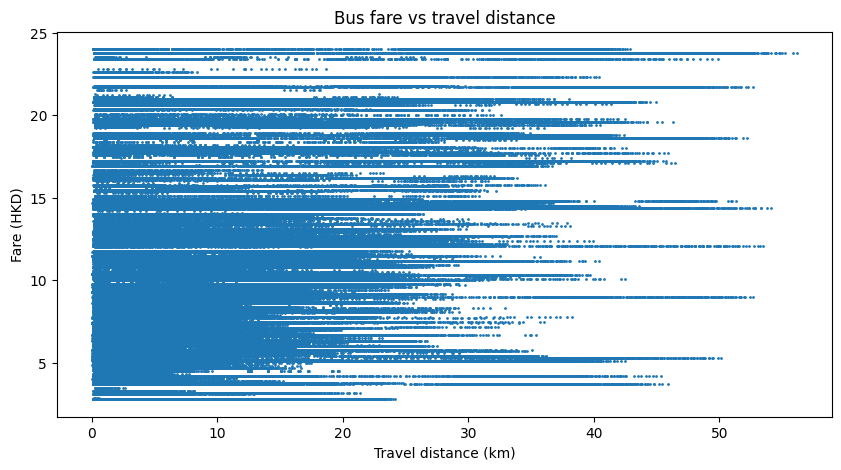

In [5]:
plt.figure(figsize=(10, 5))
plt.scatter(bus["DISTANCE"], bus["PRICE"], s=1)
plt.title("Bus fare vs travel distance")
plt.xlabel("Travel distance (km)")
plt.ylabel("Fare (HKD)")
plt.savefig("bus_fare_vs_distance.png")

In [6]:
bus["DISTANCE"].corr(bus["PRICE"])

0.4400951647463783

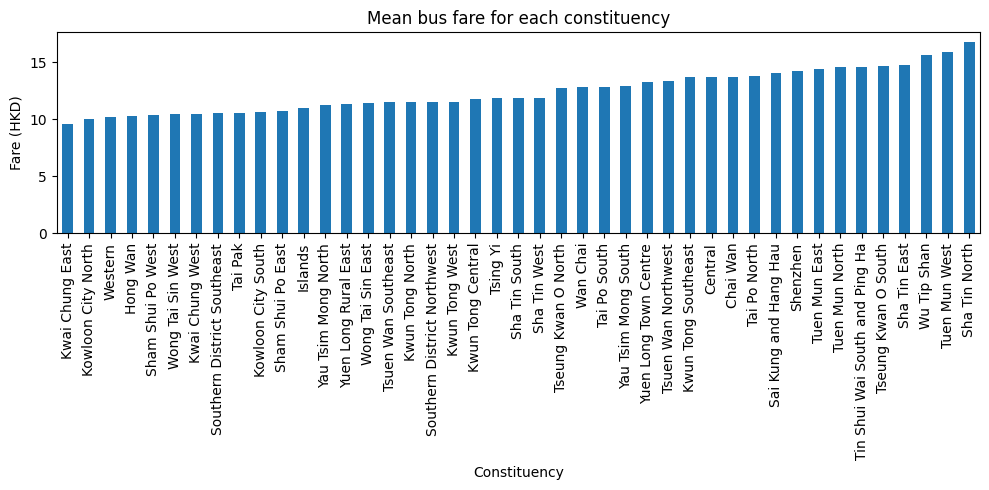

In [12]:
plt.figure(figsize=(10, 5))
bus.groupby("DISTRICT")["PRICE"].mean().sort_values().plot.bar()
plt.title("Mean bus fare for each constituency")
plt.xlabel("Constituency")
plt.ylabel("Fare (HKD)")
plt.tight_layout()
plt.savefig("bus_fare_per_district.png")